# **Mestrado em Ciência de Dados - 2.º Ano**
**Aluno:** Miguel Loureiro | 2220134

**Instituição:** Universidade de Leiria e Oeste  

***Dissertação:*** Data Mining Aplicado à Transformação Digital de uma PME Portuguesa de E-commerce: Um Caso de Estudo Integrado

---

# **Notebook 1. Compreensão dos Dados**
*O presente notebook está associado à fase de Compreensão dos Dados inserida na metodologia CRISP-DM, que será aplicada ao caso de estudo da PME do setor pet e agrícola, que opera em contexto de e-commerce.*

---

## **Contextualização do problema em estudo**

### **Contexto de aplicação**

A empresa em estudo trata-se de uma PME portuguesa dos setores pet e agrícola, com forte prevalência no segmento de **Aves**. Para a realização do presente estudo, é utilizado o dataset transacional que engloba todas as transações realizadas no período compreendido entre 13 de fevereiro de 2016 e 31 de março de 2026 (~10 anos). A data de início corresponde à primeira venda realizada aquando da criação da loja online, pelo que a base de dados inclui todas as transações realizadas desde que a PME implementou a sua loja online.

### **Objetivo desta fase**

A fase de Compreensão dos Dados da metodologia CRISP-DM visa compreender a estrutura do conjunto de dados transacionais com nome `vendas_16_26.csv`. A análise inicial do dataset permite avaliar aspetos como a qualidade dos dados e identificar padrões relevantes através da realização de uma análise exploratória de dados. O conhecimento extraído a partir desta fase será essencial para definir futuras decisões associadas a feature engineering e à fase de modelação.

### **Estrutura do dataset original**

A partir da análise inicial do dataset exportado da plataforma de e-commerce da PME em estudo, constatam-se as seguintes características:
- **Granularidade:** linha de produto, em que cada linha corresponde a um produto comprado numa venda.
- **Dimensão:** 153.100 linhas e 17 atributos.
- **Período:** 13 de fevereiro de 2016 a 31 de março de 2026.
- **Atributos:** identificadores únicos (`Ref Venda`, `Ref Cliente`, `Ref Produto`), descritivos do produto (`Nome do Produto`, `Tipo`, `Categoria`, `Subcategoria`, `Marca`), dados temporais (`Data`), transacionais (`Qt`, `Preço Produto c/IVA`, `Total Compra c/IVA`, `Desconto`, `Pagamento`), e dados do cliente (`Nome do Cliente`, `E-Mail`, `Telemóvel`).

### **Estrutura do notebook**

O presente notebook está organizado de acordo com a seguinte sequência de passos:
1. Importação de bibliotecas
2. Carregamento dos dados
3. Inspeção inicial do dataset: dimensão e amostras
4. Estrutura dos dados: tipologia das variáveis
5. Transformações iniciais: atualização de tipo de variável e criação de variáveis derivadas
6. Estatísticas descritivas
7. Avaliação da qualidade dos dados: identificação de valores em falta, duplicados, outliers, negativos inconsistentes com as regras de negócio
8. Criação de datasets agregados: dataset de vendas e de clientes
9. Análise Exploratória de Dados (EDA)
10. Exportação dos datasets
11. Principais conclusões

### **Principais outputs deste notebook**

A execução deste notebook resulta em 3 datasets diferentes, que serão essenciais para as fases subsequentes:
- **`df_linhas.csv`** - dataset original caracterizado pelo nível da linha de produto, mas agora com transformações de tipo de variáveis aplicadas.
- **`df_vendas.csv`** - dataset agregado ao nível de venda, traduzindo-se numa linha por `Ref Venda`.
- **`df_clientes.csv`** - dataset agregado ao nível do cliente, incluindo métricas ao nível de número de compras, total gasto e data da última compra.

## **1. Importação de Bibliotecas**

O primeiro passo consiste na importação das bibliotecas necessárias para as operações de manipulação, análise e visualização de dados. Como tal, foram escolhidas:
- pandas → permite a estruturação e transformação de dados tabulares
- numpy → possibilita as operações numéricas de forma eficiente
- matplotlib / seaborn → essencial para a visualização dos dados por via de elementos gráficos

In [1]:
#Importação das bibliotecas essenciais para manipulação, análise e visualização de dados
import pandas as pd               #estruturação e transformação de dados tabulares
import numpy as np                #operações numéricas eficientes
import matplotlib.pyplot as plt   #visualização
import seaborn as sns             #visualização

## **2. Carregamento dos dados**

De seguida, realiza-se, com o auxílio da ligação à Google Drive, o carregamento do dataset `vendas_16_26.csv` representado por dados transacionais em formato CSV (comma separated values). O formato escolhido permite obter maior eficiência na leitura e processamento dos dados e um menor consumo de memória.

In [2]:
#Montar a Google Drive para aceder aos ficheiros guardados
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Carregamento do dataset transacional em formato CSV
#sep=';' - separador de campos usado pelo ficheiro
#encoding='utf-8' - codificação que suporta caracteres portugueses, como por exemplo acentos e cedilhas
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("vendas_16_26.csv", sep=';', encoding='utf-8')

Saving vendas_16_26.csv to vendas_16_26.csv


/tmp/ipykernel_3357/2855446350.py:7: DtypeWarning: Columns (8,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("vendas_16_26.csv", sep=';', encoding='utf-8')


## **3. Inspeção inicial**

A realização de uma inspeção inicial dos dados visa verificar a dimensão do dataset e a validação dos dados nas primeiras e últimas 5 instâncias.

### **Estrutura do dataframe**

In [4]:
#Verificar a dimensão do dataset (linhas × colunas)
print("Dimensão:", df.shape)

Dimensão: (153100, 17)


Conclui-se que o dataset é composto por **153.100 instâncias** e **17 atributos**, representando um volume significativo de dados transacionais no período de análise.

**Observação:** Importa salientar que no dataset original ao nível da linha de venda, um registo representa a venda de um produto, podendo uma venda ser composta por mais do que um produto e, por essa razão, a mesma venda pode estar distribuída por diversas linhas.

De seguida, procede-se à visualização das 5 primeiras e últimas linhas de forma a visualizar a estrutura e o conteúdo real do dataset.

***Primeiras 5 instâncias***

In [5]:
#Visualizar as 5 primeiras linhas do dataset
df_display = df.head().copy()
# Anonimizar colunas identificáveis
for col in ['Nome do Cliente', 'E-Mail', 'Telemóvel']:
    if col in df_display.columns:
        df_display[col] = [f'[Anonimizado_{i:03d}]' for i in range(len(df_display))]
df_display


,Data,Ref Venda,Ref Cliente,Nome do Cliente,E-Mail,Telemóvel,Ref Produto,Nome do Produto,Qt,Preço Produto c/IVA,Tipo,Categoria,Subcategoria,Marca,Pagamento,Total Compra c/IVA,Desconto
0,2016-02-13,7,5,[Anonimizado_000],[Anonimizado_000],[Anonimizado_000],199,Papa Branca Húmida TH Lipo Soft - 12Kg,1,"37,4",Aves,Papas,Raggio di Sole,Raggio di Sole,Contra-Reembolso,"39,9",0
1,2016-02-15,8,7,[Anonimizado_001],[Anonimizado_001],[Anonimizado_001],553,Comedouro Cristal c/Gaveta,4,"3,2",Aves,Comedouros/Bebedouros,NaN,EX,Contra-Reembolso,"35,5",0
2,2016-02-15,8,7,[Anonimizado_002],[Anonimizado_002],[Anonimizado_002],543,Bebedouro Voadeira 600ml,1,"1,4",Aves,Comedouros/Bebedouros,NaN,EX,Contra-Reembolso,"35,5",0
3,2016-02-15,8,7,[Anonimizado_003],[Anonimizado_003],[Anonimizado_003],1671,Alimento Manutenção Micro - 350Gr.,1,"3,6",Aves,Granulados,Psittacus,Psittacus,Contra-Reembolso,"35,5",0
4,2016-02-15,8,7,[Anonimizado_004],[Anonimizado_004],[Anonimizado_004],738,Art.83 - Ninho Plastico Piriquitos,1,"3,75",Aves,Ninhos,Ninhos Diversos,2G-R,Contra-Reembolso,"35,5",0


Na análise às 5 primeiras linhas, verifica-se que:
- Existem **duas vendas distintas**, sendo que a venda com referência 7 apenas inclui um produto, ao contrário da venda com referência 8, composta por pelo menos quatro produtos distintos.
- Existem campos com **valores omissos** (por exemplo, `Subcategoria`), na medida em que apresentam caracter opcional de preenchimento. No caso da subcategoria do produto, a empresa não associou qualquer subcategoria ao produto em questão.
- Os produtos vendidos estão todos associados ao `Tipo` **Aves**, não tendo havido usufruto de qualquer `desconto` e tendo ambas as vendas como `método de pagamento` a cobrança (contra-reembolso).

Importa ainda referir que o atributo `Ref Venda` inicia na referência 7, dado que as primeiras 6 vendas serviram para testar o funcionamento da loja online e, por isso, não foram contabilizadas para análise.

Com base na análise inicial do dataset, evidencia-se a necessidade de construção dos datasets agregados por cliente e por venda, de forma a evitar a redundância de registos associados à mesma venda, dificultando as análises de fases subsquentes ao nível do cliente e da venda.

***Últimas 5 instâncias***

In [6]:
#Visualizar as 5 últimas linhas do dataset
df_display_t = df.tail().copy()
# Anonimizar colunas identificáveis
for col in ['Nome do Cliente', 'E-Mail', 'Telemóvel']:
    if col in df_display_t.columns:
        df_display_t[col] = [f'[Anonimizado_{i:03d}]' for i in range(len(df_display_t))]
df_display_t

,Data,Ref Venda,Ref Cliente,Nome do Cliente,E-Mail,Telemóvel,Ref Produto,Nome do Produto,Qt,Preço Produto c/IVA,Tipo,Categoria,Subcategoria,Marca,Pagamento,Total Compra c/IVA,Desconto
153095,2026-03-31,56048,12999,[Anonimizado_000],[Anonimizado_000],[Anonimizado_000],7422,FELIX Fantastic Seleção de Favoritos em Gelati...,7,"120,75",Gatos,Alimentação Húmida,Felix,Felix,MB Way,"114,71","6,0375"
153096,2026-03-31,56049,16720,[Anonimizado_001],[Anonimizado_001],[Anonimizado_001],6880,Fendona 6 sc 500ml,1,"61,9",Controlo de Pragas,Insectos Voadores,NaN,Basf,Multibanco,"58,8","3,09499"
153097,2026-03-31,56050,4469,[Anonimizado_002],[Anonimizado_002],[Anonimizado_002],4153,Pet Cup - Germinar Branco p/ Canários » 4kg,1,"9,45",Aves,Misturas,Pet Cup,Pet Cup,MB Way,"35,2",0
153098,2026-03-31,56050,4469,[Anonimizado_003],[Anonimizado_003],[Anonimizado_003],3821,Ornitalia - Perle Morbide » 800Gr.,1,"10,95",Aves,Misturas,Ornitália,Ornitália,MB Way,"35,2",0
153099,2026-03-31,56050,4469,[Anonimizado_004],[Anonimizado_004],[Anonimizado_004],5796,Zoopan - Bio-Sac Maximus (600Gr.),1,"10,9",Aves,Suplementos/Farmácia,Zoopan,Zoopan,MB Way,"35,2",0


Após análise das 5 últimas linhas, constata-se que:
- Existem **três vendas distintas**, cada uma relativa a tipos de produtos diferentes (*Gatos, Controlo de Pragas e Aves*).
- O atributo `Subcategoria` apresenta valores omissos à semelhança dos 5 primeiros registos, reiterando o carácter opcional do preenchimento do mesmo.
- Os pagamentos realizados derivaram do `método de pagamento` MB Way e Multibanco e, por outro lado, registou-se valor de `desconto` em duas das vendas registadas.
- A última venda regista ocorreu na `data` **31/03/2026**, reforçando a atualidade do dataset.

## **4. Estrutura dos dados**

A análise ao tipo de dados é essencial de forma a avaliar se cada atributo inserido no dataset está associado ao tipo adequado.

### **Tipos de dados**

In [7]:
#Estrutura completa do dataset: tipo de dados, número de valores não-nulos e utilização de memória
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153100 entries, 0 to 153099
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Data                 153100 non-null  object
 1   Ref Venda            153100 non-null  int64 
 2   Ref Cliente          153100 non-null  int64 
 3   Nome do Cliente      153100 non-null  object
 4   E-Mail               153100 non-null  object
 5   Telemóvel            124171 non-null  object
 6   Ref Produto          153100 non-null  int64 
 7   Nome do Produto      153100 non-null  object
 8   Qt                   153100 non-null  object
 9   Preço Produto c/IVA  153100 non-null  object
 10  Tipo                 149649 non-null  object
 11  Categoria            149501 non-null  object
 12  Subcategoria         101225 non-null  object
 13  Marca                135737 non-null  object
 14  Pagamento            153100 non-null  object
 15  Total Compra c/IVA   153100 non-nu

A análise realizada permite constatar que o dataset é composto por **17 atributos**, sendo identificados de seguida:

**- `Data`:** Data da transação

**- `Ref Venda`:** Identificador único da venda

**- `Ref Cliente`:** Identificador do cliente

**- `Nome do Cliente`:** Nome associado ao cliente

**- `E-Mail`:** Email associado ao cliente

**- `Telemóvel`:** Contacto telefónico do cliente

**- `Ref Produto`:** Identificador do produto

**- `Nome do Produto`:** Nome comercial do produto

**- `Qt`:** Quantidade de produtos adquiridos

**- `Preço Produto c/IVA`:** Preço total do produto (linha) com IVA (dependente da quantidade)

**- `Tipo`:** Categoria macro do produto (exemplo: Aves, Cães)

**- `Categoria`:** Categoria intermédia do produto

**- `Subcategoria`:** Nível mais detalhado da categorização do produto

**- `Marca`:** Marca do produto

**- `Pagamento`:** Método de pagamento utilizado

**- `Total Compra c/IVA`:** Valor total da transação c/ IVA

**- `Desconto`:** Valor de desconto aplicado

**Observações relevantes:**
- `Ref Venda`: Uma venda pode conter múltiplos produtos
- `Ref Cliente`: Pode haver múltiplos IDs/Refs para o mesmo cliente real, dado que a plataforma de e-commerce em vigor permite a realização de compras sem registo, em que um cliente realiza uma compra sem necessidade de se registar na loja online e, como tal, é-lhe atribuído um ID/Ref diferente.
- Valores omissos: Vários atributos (`Telemóvel`, `Tipo`, `Categoria`, `Subcategoria`, `Marca`) possuem registos com uma contagem inferior ao total das instâncias (153.100), comprovando a existência de valores omissos.

In [8]:
#Tipo de dados de cada coluna (verificação rápida)
df.dtypes

,0
Data,object
Ref Venda,int64
Ref Cliente,int64
Nome do Cliente,object
E-Mail,object
Telemóvel,object
Ref Produto,int64
Nome do Produto,object
Qt,object
Preço Produto c/IVA,object


Verifica-se que existem atributos que têm **tipos de dados inadequados**, sendo necessário adotar as correções necessárias.
Os principais problemas existem nas variáveis `Data`, `Qt`, `Preço Produto c/IVA`, `Total Compra c/IVA` e `Desconto`.

## **5. Transformações iniciais**

Com vista a iniciar a análise exploratória de dados, é essencial executar algumas transformações nos dados, das quais se destacam:

*   **Atualização dos tipos de dados:** verificadas inconsistências em diferentes atributos.
*   **Criação de variável derivada:** a análise cuidada dos registos comprovou que o valor do atributo `Preço Produto c/ IVA` corresponde ao valor total da quantidade adquirida do produto na encomenda, ou seja, este atributo não diz respeito ao ***Preço Unitário do produto***.

Desta forma, é necessária a criação da variável `Preco_Unitario` através da divisão entre `Preço Produto c/IVA` e `Qt`.

Esta secção inclui a definição das colunas numéricas e atualização dos seus tipos, assim como a atualização do tipo de dados da variável 'data' e a criação da variável correspondente ao preço unitário dos produtos.



### **Conversão de tipos**

In [9]:
#Lista das colunas que devem ser numéricas, que, atualmente, se encontram em formato 'object')
colunas_numericas = [
    'Qt',
    'Preço Produto c/IVA',
    'Total Compra c/IVA',
    'Desconto'
]

**Conversão de variáveis numéricas**

In [10]:
#Converter as colunas numéricas para formato decimal, substituindo vírgulas por pontos e removendo espaços
for col in colunas_numericas:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)   #vírgulas → pontos (decimais)
        .str.replace(' ', '', regex=False)    #remover espaços que possam existir
    )
    #to_numeric converte para float; errors='coerce' coloca NaN onde a conversão falhar
    df[col] = pd.to_numeric(df[col], errors='coerce')

**Conversão da data**

In [11]:
#Converter a coluna 'Data' para tipo datetime, essencial em caso de realização de análises temporais
#errors='coerce' garante que datas inválidas se tornam NaT em vez de causarem erro
df['Data'] = pd.to_datetime(df['Data'], errors='coerce')

**Validação do tipo dos atributos**

In [12]:
#Verificar se os tipos estão agora corretos
df.dtypes

,0
Data,datetime64[ns]
Ref Venda,int64
Ref Cliente,int64
Nome do Cliente,object
E-Mail,object
Telemóvel,object
Ref Produto,int64
Nome do Produto,object
Qt,float64
Preço Produto c/IVA,float64


A verificação do tipo de dados dos atributos permite agora constatar que todos os atributos numéricos e respeitantes à data estão agora devidamente associados ao tipo adequado.

### **Criação da variável Preco_Unitario**

A criação da variável `Preco_Unitario` permite identificar claramente o preço unitário de cada produto, independentemente da quantidade adquirida.

In [13]:
#Criar variável derivada: Preço Unitário = Preço Total da linha / Quantidade comprada
#Útil para análise de outliers e padrões de preço, independentemente da quantidade
df['Preco_Unitario'] = df['Preço Produto c/IVA'] / df['Qt']

## **6. Estatísticas descritivas**

A análise de estatísticas descritivas permite compreender a distribuição das diferentes variáveis que integram o conjunto de dados, assim como identificar eventuais padrões e assimetrias.

In [14]:
#Estatísticas descritivas das variáveis numéricas (count, mean, std, min, quartis, max)
df.describe()

,Data,Ref Venda,Ref Cliente,Ref Produto,Qt,Preço Produto c/IVA,Total Compra c/IVA,Desconto,Preco_Unitario
count,153100,153100.000000,153100.000000,153100.000000,153100.000000,153100.00000,153100.000000,153100.000000,152976.000000
mean,2022-07-09 00:51:47.239712768,27269.274618,5934.801039,3366.601541,2.407461,24.43306,79.734388,0.114718,18.674050
min,2016-02-13 00:00:00,7.000000,1.000000,1.000000,0.000000,0.00000,0.170000,0.000000,0.159833
25%,2020-10-07 00:00:00,13351.750000,2494.000000,615.000000,1.000000,5.95000,42.700000,0.000000,3.600000
50%,2022-08-07 00:00:00,26279.000000,5320.000000,3987.000000,1.000000,14.40000,63.050000,0.000000,11.500000
75%,2024-08-04 00:00:00,41435.000000,8682.000000,5436.000000,2.000000,32.00000,94.400000,0.000000,26.500000
max,2026-03-31 00:00:00,56050.000000,16720.000000,11508.000000,400.000000,1180.00000,1577.000000,84.350100,725.000000
std,NaN,16178.917846,4161.881422,2530.531398,5.185793,32.25480,66.749969,1.208163,24.587007


A análise das estatísticas descritivas ao nível da **linha de venda** deve ser realizada com cautela, dado que algumas das variáveis (ex: `Total Compra c/IVA`) encontram-se replicadas nas diferentes linhas associadas à mesma venda.

Verifica-se que as variáveis quantitativas são caracterizadas por uma distribuição assimétrica à direita, verificando-se uma **elevada concentração de valores baixos**.

- `Qt` (Quantidade): A maioria das linhas representa a venda de uma ou duas unidades do produto, conforme evidenciado pela mediana de 1 unidade e pelo terceiro quartil de 2 unidades. Contudo, existem casos em que o mesmo produto apresenta uma quantidade significativa de venda (máximo = 400), aumentando o valor médio para 2,41 unidades e indicando produtos de valor reduzido e com desconto em quantidade (exemplo: bebedouros e comedouros para aves). Importa ainda salientar que existem situações de quantidades iguais a zero (mínimo = 0), indicando possíveis erros no sistema, dado que, por norma, não é possível adicionar ao carrinho produtos com quantidade nula.

- `Total Compra c/IVA` e `Preco_Unitario`: Tal como acontece na variável Qt, é evidente uma forte distribuição assimétrica positiva, caracterizada pelas diferenças entre média e mediana.

- `Desconto`: possui valores maioritariamente nulos nas diferentes medidas, dando a entender que a prática de desconto não é algo comum na empresa em análise.

### **Valores inconsistentes**

***Nº de registos com Quantidade = 0***

In [15]:
#Contar registos com quantidade igual a zero (eventuais erros do sistema)
(df['Qt'] == 0).sum()

np.int64(124)

Ao analisar os valores da `Qt` adquirida por linha de produto, constata-se que existem **124 instâncias** em que a quantidade é igual a zero, retratando, como referido anteriormente, possíveis erros no sistema. Dado que se tratam de situações inconsistentes com a validade de uma transação e representam apenas 124 registos num total de 153.100, opta-se pela remoção das mesmos.

***Remoção das instâncias com Quantidade = 0***

In [16]:
#Remover linhas com Qt=0 (inconsistentes com a regra de transação válida)
df = df[df['Qt'] != 0]

In [17]:
#Confirmar que já não existem registos com Qt=0
(df['Qt'] == 0).sum()

np.int64(0)

***Validação da remoção***

In [18]:
#Estatísticas descritivas após remoção dos registos inválidos
df.describe()

,Data,Ref Venda,Ref Cliente,Ref Produto,Qt,Preço Produto c/IVA,Total Compra c/IVA,Desconto,Preco_Unitario
count,152976,152976.000000,152976.000000,152976.000000,152976.000000,152976.000000,152976.000000,152976.000000,152976.000000
mean,2022-07-09 05:31:55.782868224,27273.200626,5934.868960,3366.725957,2.409413,24.452865,79.742596,0.114811,18.674050
min,2016-02-13 00:00:00,7.000000,1.000000,1.000000,0.300000,0.170000,0.170000,0.000000,0.159833
25%,2020-10-07 00:00:00,13352.000000,2494.000000,615.000000,1.000000,5.950000,42.750000,0.000000,3.600000
50%,2022-08-07 00:00:00,26289.000000,5320.000000,3988.000000,1.000000,14.400000,63.050000,0.000000,11.500000
75%,2024-08-04 00:00:00,41442.000000,8684.000000,5436.000000,2.000000,32.050000,94.400000,0.000000,26.500000
max,2026-03-31 00:00:00,56050.000000,16720.000000,11508.000000,400.000000,1180.000000,1577.000000,84.350100,725.000000
std,NaN,16180.420302,4162.411749,2530.710677,5.187441,32.260365,66.747461,1.208648,24.587007


Após remoção das instâncias com Qt = 0, o dataset atualizado é composto por **152.976 registos**. Verifica-se agora que a quantidade mínima adquirida por linha de produto é 0,3, correspondendo à venda de 300 gramas de um produto de 1kg, mas cuja compra pôde, efetivamente, ser definida em gramas pelo cliente.

## **7. Avaliação da Qualidade dos Dados**

A avaliação da qualidade dos dados é realizada através da identificação e análise de **valores omissos, duplicados, negativos** e da existência de **outliers**.

### **Valores em falta**

In [19]:
#Contagem absoluta de valores em falta por atributo
print("Valores em falta:")
df.isnull().sum()

Valores em falta:


,0
Data,0
Ref Venda,0
Ref Cliente,0
Nome do Cliente,0
E-Mail,0
Telemóvel,28906
Ref Produto,0
Nome do Produto,0
Qt,0
Preço Produto c/IVA,0


In [20]:
#Percentagem de valores em falta por atributo
print((df.isnull().mean()*100).round(2))

Data                    0.00
Ref Venda               0.00
Ref Cliente             0.00
Nome do Cliente         0.00
E-Mail                  0.00
Telemóvel              18.90
Ref Produto             0.00
Nome do Produto         0.00
Qt                      0.00
Preço Produto c/IVA     0.00
Tipo                    2.25
Categoria               2.35
Subcategoria           33.87
Marca                  11.34
Pagamento               0.00
Total Compra c/IVA      0.00
Desconto                0.00
Preco_Unitario          0.00
dtype: float64


A análise aos **valores omissos** revela que a maioria das variáveis do dataset apresenta níveis de completude bastante elevados, não sendo identificados valores omissos nas variáveis transacionais que apresentam maior relevância para o trabalho a desenvolver, como por exemplo, `Ref Venda`, `Ref Cliente`, `Qt`, `Total Compra c/IVA`, `Desconto` e `Preco_Unitario`.

Contudo, existem variáveis com elevada percentagem de valores omissos, tais como `Subcategoria` (33,87%), `Telemóvel` (18,90%) `Marca` (11,34%). Adicionalmente, com menos significância a nível percentual, constam as variáveis `Tipo` (2,25%) e `Categoria` (2,35%).

No caso das variáveis categóricas associadas às características dos produtos, a incompletude registada está associada à ausência de classificação dos produtos quanto ao seu `tipo`, `categoria`, `subcategoria` e `marca`, sendo algo que tem vindo a ser trabalhado mais recentemente de forma a promover uma melhor compreensão e categorização dos produtos.

No que diz respeito à variável `Telemóvel`, a percentagem de valores omissos registada está associada ao carácter opcional de preenchimento deste campo pelo utilizador aquando do seu registo.

Resumidamente, os valores omissos estão concentrados em variáveis de cariz descritivo. No caso das variáveis `Subcategoria` e `Telemóvel`, os valores omissos não têm implicações na fase de modelação, pois não serão utilizadas nos modelos. No entanto, as variáveis `Tipo`, `Categoria` e `Marca` são utilizadas para a criação de features derivadas no problema de classificação e de clustering, pelo que serão tratados de formas distintas em cada uma dessas situações sem necessidade de remoção dos registos.

### **Valores Duplicados**

A análise de **valores duplicados** é relevante, no entanto importa salientar que neste caso específico são analisadas linhas exatamente iguais em todos os atributos, pois tratando-se de uma base de dados de linha de produto existem, por exemplo, diversas linhas com a mesma venda ou diferentes linhas com o mesmo cliente, não devendo estas situações ser interpretadas como duplicação de dados.

In [21]:
#Contagem de linhas exatamente duplicadas (todas as colunas iguais)
print("Duplicados:")
df.duplicated().sum()

Duplicados:


np.int64(5)

In [22]:
#Visualizar as linhas duplicadas para análise manual
df_display = df[df.duplicated(keep=False)].sort_values(by='Ref Venda').copy()
# Anonimizar colunas identificáveis
for col in ['Nome do Cliente', 'E-Mail', 'Telemóvel']:
    if col in df_display.columns:
        df_display[col] = [f'[Anonimizado_{i:03d}]' for i in range(len(df_display))]
df_display

,Data,Ref Venda,Ref Cliente,Nome do Cliente,E-Mail,Telemóvel,Ref Produto,Nome do Produto,Qt,Preço Produto c/IVA,Tipo,Categoria,Subcategoria,Marca,Pagamento,Total Compra c/IVA,Desconto,Preco_Unitario
29602,2020-04-29,10577,5196,[Anonimizado_000],[Anonimizado_000],[Anonimizado_000],3437,Luva Juba ´´Eco-PU´´ Preta (8),1.0,1.2,Material de Proteção,Luvas,NaN,NaN,Multibanco,41.2,0.0,1.2
29603,2020-04-29,10577,5196,[Anonimizado_001],[Anonimizado_001],[Anonimizado_001],3437,Luva Juba ´´Eco-PU´´ Preta (8),1.0,1.2,Material de Proteção,Luvas,NaN,NaN,Multibanco,41.2,0.0,1.2
126430,2025-02-25,45864,13007,[Anonimizado_002],[Anonimizado_002],[Anonimizado_002],6178,Pet Cup - Papagaios Special Fruit Mix (10kg),1.0,32.0,Aves,Misturas,Pet Cup,Pet Cup,MB Way,451.4,0.0,32.0
126433,2025-02-25,45864,13007,[Anonimizado_003],[Anonimizado_003],[Anonimizado_003],6178,Pet Cup - Papagaios Special Fruit Mix (10kg),1.0,32.0,Aves,Misturas,Pet Cup,Pet Cup,MB Way,451.4,0.0,32.0
129398,2025-04-11,46977,13890,[Anonimizado_004],[Anonimizado_004],[Anonimizado_004],7850,PRO PLAN Large Athletic Adult Frango (14+2.5kg),1.0,56.0,Cães,Alimentação,PRO PLAN (PROMO),(Purina) Pro Plan,Multibanco,100.8,11.2,56.0
129399,2025-04-11,46977,13890,[Anonimizado_005],[Anonimizado_005],[Anonimizado_005],7850,PRO PLAN Large Athletic Adult Frango (14+2.5kg),1.0,56.0,Cães,Alimentação,PRO PLAN (PROMO),(Purina) Pro Plan,Multibanco,100.8,11.2,56.0
130038,2025-04-23,47241,13859,[Anonimizado_006],[Anonimizado_006],[Anonimizado_006],7847,PRO PLAN Sterilized Peru 12kg (10+2kg),1.0,56.5,Gatos,Alimentação,PRO PLAN (PROMO),(Purina) Pro Plan,MB Way,101.7,11.3,56.5
130039,2025-04-23,47241,13859,[Anonimizado_007],[Anonimizado_007],[Anonimizado_007],7847,PRO PLAN Sterilized Peru 12kg (10+2kg),1.0,56.5,Gatos,Alimentação,PRO PLAN (PROMO),(Purina) Pro Plan,MB Way,101.7,11.3,56.5
152648,2026-03-27,55881,16663,[Anonimizado_008],[Anonimizado_008],[Anonimizado_008],7846,PRO PLAN Sterilized Salmão 10kg +2kg (10+2kg),1.0,56.5,Gatos,Alimentação,PRO PLAN (PROMO),(Purina) Pro Plan,MB Way,113.0,0.0,56.5
152649,2026-03-27,55881,16663,[Anonimizado_009],[Anonimizado_009],[Anonimizado_009],7846,PRO PLAN Sterilized Salmão 10kg +2kg (10+2kg),1.0,56.5,Gatos,Alimentação,PRO PLAN (PROMO),(Purina) Pro Plan,MB Way,113.0,0.0,56.5


A partir da análise manual dos **5 registos duplicados**, correspondendo a um total de 10 linhas, verifica-se que os clientes em questão adicionaram o mesmo produto ao carrinho duas vezes de forma individual em vez de aumentarem a quantidade. Esta evidência é revelada, dado que as linhas em análise partilham a mesma referência de venda, a mesma referência de cliente, a mesma referência de produto, a mesma quantidade e o mesmo preço. Desta forma, interpretam-se estes registos como um comportamento real do cliente, não sendo necessária a remoção dos mesmos.

### **Valores Extremos / Outliers**

A análise de outliers visa identificar **valores extremos** nas diferentes variáveis numéricas que integram o dataset. Esta análise permite avaliar se estes valores estão associados a comportamentos reais dos clientes ou a eventuais inconsistências nos dados.

Neste caso não é considerada a variável `Preço Produto c/IVA`, dado que não representa o preço unitário do produto, mas sim o valor total gasto no produto tendo em consideração a quantidade adquirida. Em alternativa, será integrada a variável `Preco_Unitario`.

***Boxplots agregados***

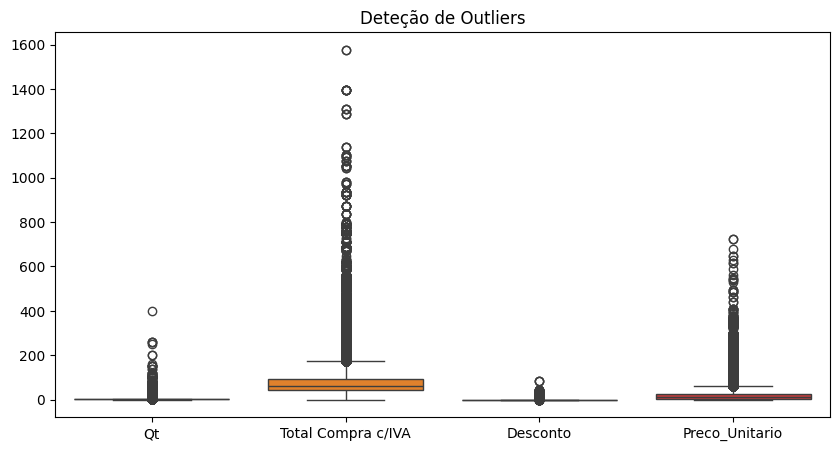

In [23]:
#Boxplot agregado das 4 variáveis numéricas relevantes
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Qt', 'Total Compra c/IVA', 'Desconto', 'Preco_Unitario']])
plt.title("Deteção de Outliers")
plt.show()

***Boxplot Preço Unitário***

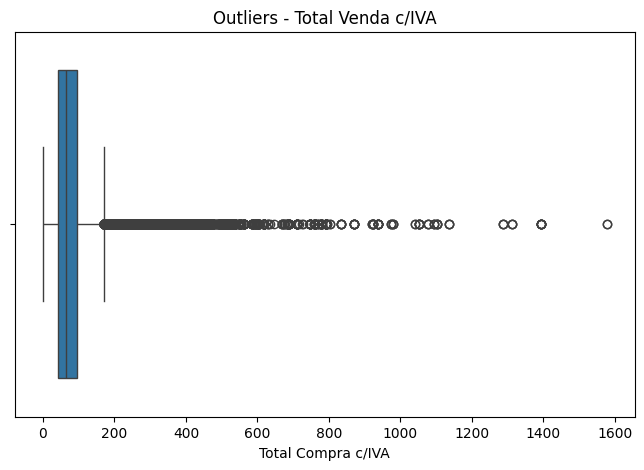

In [24]:
#Boxplot individual do Total de Venda - análise focada
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Total Compra c/IVA'])
plt.title("Outliers - Total Venda c/IVA")
plt.show()

***Boxplot Total de Venda c/ IVA***

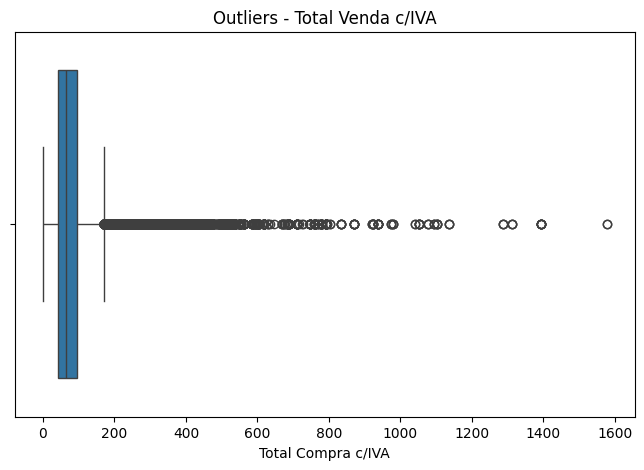

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Total Compra c/IVA'])
plt.title("Outliers - Total Venda c/IVA")
plt.show()

***Aplicação do método IQR para obter número e percentagem de outliers***

In [26]:
#Função para detetar outliers pelo método IQR (Interquartile Range)
#Outlier = valor abaixo de Q1-1.5*IQR ou acima de Q3+1.5*IQR
def analisar_outliers(col):
    Q1 = df[col].quantile(0.25)            #1º quartil (25%)
    Q3 = df[col].quantile(0.75)            #3º quartil (75%)
    IQR = Q3 - Q1                          #amplitude interquartil

    limite_inf = Q1 - 1.5 * IQR            #limite inferior
    limite_sup = Q3 + 1.5 * IQR            #limite superior

    #Filtrar registos fora dos limites
    outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)]

    return {
        'Variavel': col,
        'Num_Outliers': len(outliers),
        'Percentagem': len(outliers) / len(df) * 100
    }

#Aplicar a função a todas as variáveis numéricas relevantes
variaveis = ['Qt', 'Total Compra c/IVA', 'Desconto', 'Preco_Unitario']

resultados = []
for var in variaveis:
    resultados.append(analisar_outliers(var))

df_outliers = pd.DataFrame(resultados)
df_outliers

,Variavel,Num_Outliers,Percentagem
0,Qt,19893,13.004001
1,Total Compra c/IVA,10305,6.736351
2,Desconto,2651,1.732952
3,Preco_Unitario,5938,3.881655


Com base nos boxplots apresentados e no método IQR, verifica-se a presença de valores extremos nas diferentes variáveis numéricas, sendo a variável `Qt` a que apresenta mais ocorrências (19.893), correspondendo a 13% do total de registos.

Contudo, os valores extremos identificados não são considerados erros e serão mantidos, na medida em que refletem as características e volatibilidade do comportamento de compra dos clientes e da variedade de produtos da empresa.

Nos casos identificados na variável `Qt`, constata-se, através de análise manual, que a maioria das compras com volume elevado correspondem a transações legítimas de clientes profissionais (ex: criadores de aves), que normalmente assumem comportamentos de compra em escala, beneficiando de descontos em quantidade. Desta forma, a sua remoção iria introduzir um viés na análise.

Adicionalmente, os outliers associados à variável `Total Compra c/IVA` podem ser interpretados como correspondentes a compras com elevado valor. Como esta interpretação é realizada ao nível da linha de venda, existe replicação de valores associados à mesma venda, podendo levar a uma maior perceção de outliers.

No caso da variável `Desconto`, em que a maioria das compras não apresenta desconto, os valores positivos mais elevados podem ser identificados como outliers, resultando em situações pontuais associadas a descontos mais significativos.

Por fim, os outliers associados à variável `Preco_Unitario` traduzem elevada variabilidade dos preços, indicando também a presença de produtos com um preço unitário elevado.

Desta forma, opta-se por não remover estes valores, dado que contêm informação útil relativamente ao comportamento de compra dos clientes e à estrutura do negócio em análise. A remoção dos outliers iria eliminar clientes que em questões de segmentação poderão constituir clusters de elevado valor para a empresa.

### **Valores negativos**

A verificação da existência de valores negativos nas variáveis `Preco_Unitario`, `Qt` e `Total Compra c/IVA` visa identificar inconsistências nos dados, dado que o preço unitário do produto não pode, de forma lógica, ser negativo, a quantidade comprada de um produto também não pode assumir valores negativos, assim como o total de uma compra não pode ser negativo.

In [27]:
#Verificar se existem registos com Preço Unitário negativo
df[df['Preco_Unitario'] < 0]

,Data,Ref Venda,Ref Cliente,Nome do Cliente,E-Mail,Telemóvel,Ref Produto,Nome do Produto,Qt,Preço Produto c/IVA,Tipo,Categoria,Subcategoria,Marca,Pagamento,Total Compra c/IVA,Desconto,Preco_Unitario


In [28]:
#Verificar se existem registos com Quantidade negativa
df[df['Qt'] < 0]

,Data,Ref Venda,Ref Cliente,Nome do Cliente,E-Mail,Telemóvel,Ref Produto,Nome do Produto,Qt,Preço Produto c/IVA,Tipo,Categoria,Subcategoria,Marca,Pagamento,Total Compra c/IVA,Desconto,Preco_Unitario


In [29]:
#Verificar se existem registos com Total Compra negativo
df[df['Total Compra c/IVA'] < 0]

,Data,Ref Venda,Ref Cliente,Nome do Cliente,E-Mail,Telemóvel,Ref Produto,Nome do Produto,Qt,Preço Produto c/IVA,Tipo,Categoria,Subcategoria,Marca,Pagamento,Total Compra c/IVA,Desconto,Preco_Unitario


A verificação realizada confirmou que não existem valores negativos nas variáveis numéricas relevantes. Desta forma, os dados são consistentes com as regras de negócio e não incluem erros contextuais.

## **8. Criação de datasets agregados**

A estrutura do dataset original ao nível da linha de venda pressupõe a criação de dois datasets agregados ao nível da venda e do cliente, de forma a ser possível realizar análises mais adequadas ao estudo do comportamento de compra dos clientes da empresa.

A criação dos datasets agregados reduz a redundância no dataset original e permite analisar cuidadosamente aspetos como o valor total de compras e a frequência de aquisição.

### **Dataset Vendas**

In [30]:
#Criar dataset agregado ao nível da VENDA (uma linha por Ref Venda)
#drop_duplicates mantém apenas a primeira ocorrência de cada Ref Venda: agregação trivial dado que as colunas a manter são as mesmas em cada linha da venda
df_vendas = df.drop_duplicates(subset='Ref Venda')

In [31]:
#Confirmar dimensão do novo dataset de vendas
print("Dimensão:", df_vendas.shape)

Dimensão: (55971, 18)


A criação do dataset agregado de Vendas resulta da eliminação dos registos duplicados a partir do identificador único de venda (`Ref Venda`), levando a que o volume de observações reduza substancialmente para **55.971 registos**.

***Primeiras 5 instâncias***

In [32]:
#Visualizar primeiras 5 vendas (agora cada linha é igual a uma venda completa)
df_display = df_vendas.head().copy()
# Anonimizar colunas identificáveis
for col in ['Nome do Cliente', 'E-Mail', 'Telemóvel']:
    if col in df_display.columns:
        df_display[col] = [f'[Anonimizado_{i:03d}]' for i in range(len(df_display))]
df_display

,Data,Ref Venda,Ref Cliente,Nome do Cliente,E-Mail,Telemóvel,Ref Produto,Nome do Produto,Qt,Preço Produto c/IVA,Tipo,Categoria,Subcategoria,Marca,Pagamento,Total Compra c/IVA,Desconto,Preco_Unitario
0,2016-02-13,7,5,[Anonimizado_000],[Anonimizado_000],[Anonimizado_000],199,Papa Branca Húmida TH Lipo Soft - 12Kg,1.0,37.40,Aves,Papas,Raggio di Sole,Raggio di Sole,Contra-Reembolso,39.90,0.0,37.40
1,2016-02-15,8,7,[Anonimizado_001],[Anonimizado_001],[Anonimizado_001],553,Comedouro Cristal c/Gaveta,4.0,3.20,Aves,Comedouros/Bebedouros,NaN,EX,Contra-Reembolso,35.50,0.0,0.80
13,2016-02-19,9,8,[Anonimizado_002],[Anonimizado_002],[Anonimizado_002],199,Papa Branca Húmida TH Lipo Soft - 12Kg,1.0,37.40,Aves,Papas,Raggio di Sole,Raggio di Sole,Contra-Reembolso,99.00,0.0,37.40
17,2016-02-24,10,7,[Anonimizado_003],[Anonimizado_003],[Anonimizado_003],548,Bebedouro Automático Copo Balanço Entrada 12mm,1.0,2.40,Aves,Comedouros/Bebedouros,NaN,Diversos,Contra-Reembolso,35.10,0.0,2.40
27,2016-02-28,11,9,[Anonimizado_004],[Anonimizado_004],[Anonimizado_004],3974,CHEMI-VIT - Victor Respiroil Liquido - 200ml,1.0,11.15,Aves,Suplementos/Farmácia,Chemi-Vit,Chemi-Vit,Contra-Reembolso,32.25,0.0,11.15


### **Dataset Clientes**

In [33]:
#Antes do groupby, normalizar Nome do Cliente para mitigar variações textuais
df_vendas['Nome do Cliente'] = (
    df_vendas['Nome do Cliente']
    .fillna('Desconhecido')
    .str.strip()                            # remover espaços nas extremidades
    .str.replace(r'\s+', ' ', regex=True)   # múltiplos espaços → um espaço
    .str.title()                            # capitalização consistente
)

/tmp/ipykernel_3357/454610554.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vendas['Nome do Cliente'] = (


In [34]:
#Criar dataset agregado ao nível do CLIENTE (uma linha por Ref Cliente)
df_clientes = df_vendas.groupby('Ref Cliente').agg({
    'Nome do Cliente': 'first',         # nome consolidado: primeira ocorrência
    'Ref Venda': 'count',               # número de compras realizadas
    'Total Compra c/IVA': 'sum',        # soma de tudo o que gastou
    'Data': 'max'                       # data da compra mais recente
}).reset_index()

#Renomear colunas para a nomenclatura RFM canónica
df_clientes.columns = [
    'Ref Cliente',
    'Nome do Cliente',
    'Frequency',
    'Monetary',
    'Ultima_Compra'
]

#Confirmar unicidade do Ref Cliente
assert df_clientes['Ref Cliente'].is_unique, \
    'Duplicação de Ref Cliente detetada - investigar dados de origem'

print(f'Clientes únicos: {len(df_clientes):,}')

Clientes únicos: 13,074


In [35]:
#Confirmar dimensão do dataset de clientes
print("Dimensão:", df_clientes.shape)

Dimensão: (13074, 5)


O dataset agregado de clientes apresenta **13.074 registos**, correspondendo ao número de clientes distintos registados no sistema associado à loja online da empresa em análise durante o periodo de fevereiro de 2016 e março de 2026.

Para a criação deste dataset, procedeu-se à agregação de todas as transações ao nível do cliente, possibilitando criar variáveis relevantes, como por exemplo o número de compras realizadas pelo cliente (`Frequency`), o valor total gasto pelo cliente (`Monetary`) e a data da última compra realizada pelo cliente (`Ultima_Compra`).

***Primeiras 5 instâncias***

In [36]:
#Visualizar primeiros 5 clientes
df_display = df_clientes.head().copy()
# Anonimizar colunas identificáveis
for col in ['Nome do Cliente', 'E-Mail', 'Telemóvel']:
    if col in df_display.columns:
        df_display[col] = [f'[Anonimizado_{i:03d}]' for i in range(len(df_display))]
df_display

,Ref Cliente,Nome do Cliente,Frequency,Monetary,Ultima_Compra
0,1,[Anonimizado_000],23,1236.54,2025-01-21
1,2,[Anonimizado_001],11,248.09,2025-05-21
2,4,[Anonimizado_002],86,8177.29,2026-03-31
3,5,[Anonimizado_003],1,39.90,2016-02-13
4,7,[Anonimizado_004],99,3982.89,2026-03-22


***Análise de clientes duplicados***

Conforme referido anteriormente, o sistema da loja online permite aos clientes realizar compras sem registo, possibilitando que a um mesmo cliente, ao comprar diversas vezes recorrendo a este método, lhe sejam atribuídos diversas `Ref Cliente`. Desta forma, torna-se essencial avaliar a possível existência de clientes duplicados através da correspondência entre o nome do cliente e o identificador (Ref Cliente).

In [37]:
#Identificar clientes com mais de uma Ref Cliente associada ao mesmo Nome (indicador de possíveis duplicados causados por compras sem registo)
clientes_dup = df.groupby('Nome do Cliente')['Ref Cliente'].nunique()
num_clientes_duplicados = (clientes_dup > 1).sum()

num_clientes_duplicados

np.int64(550)

In [38]:
#Percentagem de possíveis duplicações
(clientes_dup > 1).mean() * 100

np.float64(4.47227191413238)

In [39]:
#Top 10 nomes com mais Ref Cliente associadas para análise manual
df_display = df.groupby('Nome do Cliente')['Ref Cliente'].nunique().sort_values(ascending=False).head(10).reset_index()
# Anonimizar colunas identificáveis
for col in ['Nome do Cliente', 'E-Mail', 'Telemóvel']:
    if col in df_display.columns:
        df_display[col] = [f'[Anonimizado_{i:03d}]' for i in range(len(df_display))]
df_display

,Nome do Cliente,Ref Cliente
0,[Anonimizado_000],14
1,[Anonimizado_001],11
2,[Anonimizado_002],9
3,[Anonimizado_003],8
4,[Anonimizado_004],7
5,[Anonimizado_005],7
6,[Anonimizado_006],6
7,[Anonimizado_007],6
8,[Anonimizado_008],6
9,[Anonimizado_009],6


A duplicação de dados existente totaliza **550 registos**, correspondendo a 4,47% do total de registos. Os registos duplicados levam à subestimação de aspetos como a frequência de compra e o valor gasto pelos clientes, dada a distribuição dos registos do mesmo cliente por diferentes identificadores.

Contudo, opta-se pela utilização da variável `Ref Cliente` como unidade principal de análise, dado o valor percentual reduzido de duplicados encontrado, a possível existência de homónimos genuinamente distintos e a inexistência de outra forma mais fiável de agregar os registos de um mesmo cliente sem a introdução de eventuais erros. Esta decisão será tida em consideração na interpretação dos resultados a obter.

### **Síntese dos datasets gerados**

Os três datasets complementares produzidos são caracterizados de seguida:

| Dataset | Granularidade | Nº de registos | Utilização |
|---|---|---|---|
| `df_linhas` | Linha de produto | 152.976 | Regras de associação |
| `df_vendas` | Venda (transação) | 55.971 | EDA temporal e métricas agregadas |
| `df_clientes` | Cliente único | 13.074 | Classificação e Clustering |

A hierarquia estabelecida entre os três datasets é traduzida por: o `df_linhas` detém a granularidade máxima, o `df_vendas` agrega ao nível da transação e o `df_clientes` integra ao nível do cliente as variáveis comportamentais que servirão de base à modelação.

## **9. Análise Exploratória de Dados**

A **Análise Exploratória de Dados** permite compreender os padrões, as relações e as características do conjunto de dados em análise. Desta forma, é possível identificar *tendências, distribuições e eventuais anomalias*.

Esta etapa é caracterizada pela análise das variáveis associadas às vendas, clientes e produtos, permitindo extrair conhecimento útil sobre o comportamento de compra dos clientes da empresa. Como tal, serão dadas respostas às seguintes questões:

- Existe relação entre as variáveis principais (valor, quantidade, preço, desconto)?

- Existem outliers na variável valor de compra?

- Como evoluem as vendas ao longo do tempo?

- Como se distribui o valor das compras?

- Qual o número de produtos por venda?

- Quais os tipos e as categorias mais relevantes?

- Quais os métodos de pagamento mais utilizados?

- Como está distribuído o número de compras por cliente?

- Como está distribuído o valor gasto por cliente?

- Existe concentração de receita em poucos clientes?

- Existe relação entre frequência e valor ao nível do cliente?

- Quais os produtos e marcas mais relevantes?

### **Matriz de Correlação**

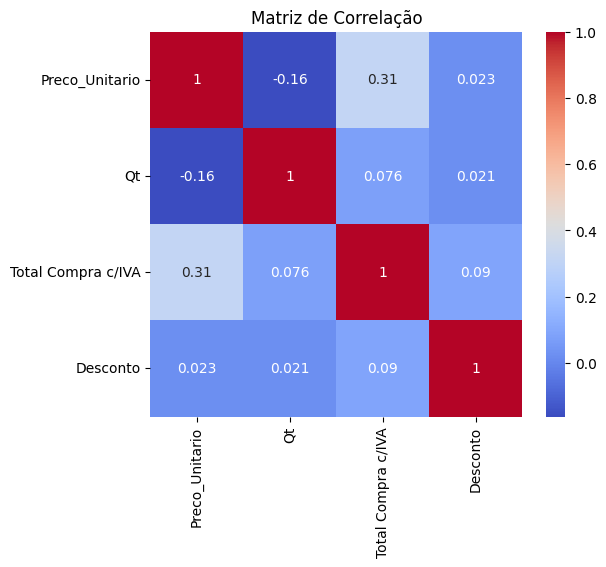

In [40]:
#Matriz de correlação entre as variáveis numéricas relevantes
#Mede a força e direção das relações lineares (valores variam entre -1 e 1)
corr = df[['Preco_Unitario','Qt','Total Compra c/IVA','Desconto']].corr()

#Visualizar como heatmap (cmap='coolwarm': azul=correlação negativa, vermelho=positiva)
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de Correlação")
plt.show()

A matriz de correlação acima apresentada constata que existem **relações fracas entre as variáveis numéricas em análise**, traduzindo uma baixa dependência linear.

A relação entre a variável `Preco_Unitario` e `Total Compra c/IVA` traduz-se numa **correlação positiva moderada**, assumindo um coeficiente de 0,31, indicando que produtos com um valor unitário maior tendem a estar associados a compras de maior valor monetário.

A variável `Qt` apresenta **correlações bastante reduzidas**, muito próximas de 0, com as restantes variáveis, levando a que se assuma que a quantidade de produtos ao nível da linha de venda não influencie significativamente o preço unitário do produto nem o valor da compra. Este tipo de correlação pode ser justificado pela elevada diversidade de preços dos produtos. No caso do preço unitário com a quantidade, verifica-se uma correlação negativa fraca, sugerindo que produtos mais caros sejam adquiridos em menor quantidade.

Na variável `Desconto` constata-se a existência de **correlações igualmente reduzidas**, indicando que a existência de descontos não influencia de forma significativa a quantidade comprada, o preço unitário dos produtos e o valor total da compra. Esta realidade pode ser explicada pela adoção mínima de descontos praticados pela empresa.

Assim, verifica-se que não existe multicolinearidade significativa entre as diferentes variáveis, levando a que a inclusão destas variáveis na fase de modelação não acarrete riscos elevados de redundância de informação.

### **Outliers - Dataframe Vendas: Valor de Compra**

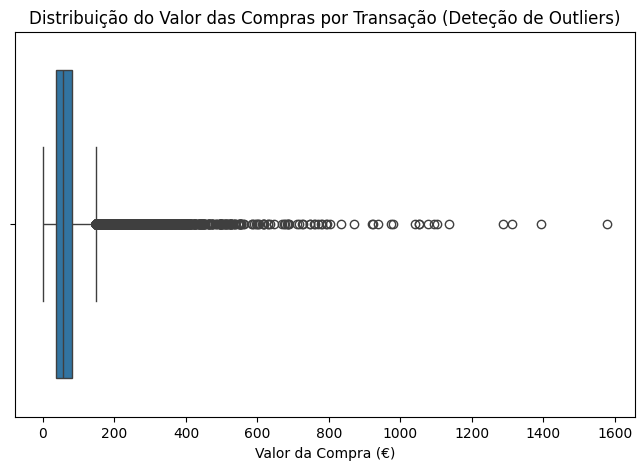

In [41]:
#Boxplot do Valor de Compra ao nível da venda (sem replicação por linha de venda)
plt.figure(figsize=(8,5))

sns.boxplot(x=df_vendas['Total Compra c/IVA'])

plt.title("Distribuição do Valor das Compras por Transação (Deteção de Outliers)")
plt.xlabel("Valor da Compra (€)")

plt.show()

De forma a complementar a análise de outliers já realizada no dataset original, é realizada a identificação de valores extremos respeitantes à variável `Total Compra c/IVA` no dataset agregado de vendas, evitando replicação de registos.

A análise ao boxplot acima permite verificar que existe uma **distribuição assimétrica forte e positiva**, dado que a maioria das compras realizadas apresenta valores baixos. Adicionalmente, constata-se a existência de um número significativo de valores extremos, que correspondem a compras com valores elevados.

Desta forma, a distribuição evidenciada é compatível com os padrões tipicamente observados em contexto de e-commerce, que usualmente se caracterizam por um número elevado de transações de baixo valor e um número reduzido de compras com elevado valor. Esta conclusão é relevante para a realização de análise de receita e processos de segmentação de clientes.

### **Vendas:**

#### **Evolução das vendas**

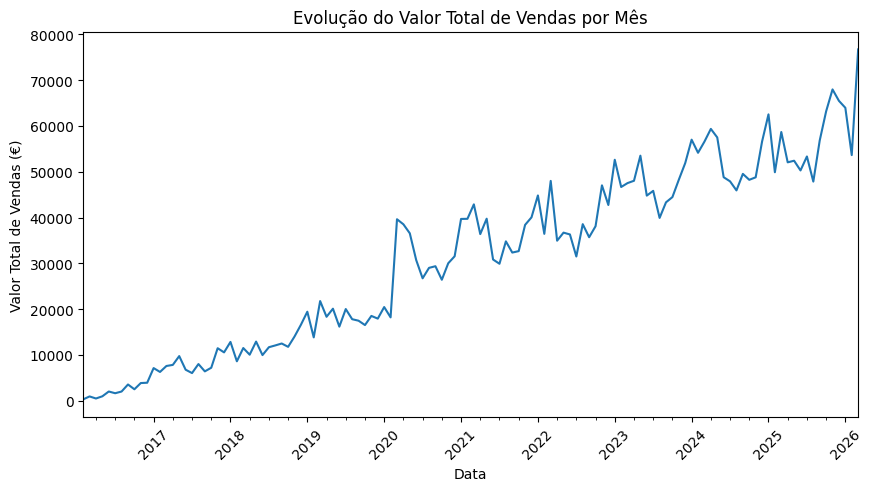

In [42]:
#Evolução temporal das vendas com agregação mensal do valor total
plt.figure(figsize=(10,5))

#to_period('M') agrupa por mês; sum() soma o valor de todas as vendas desse mês
vendas_mensais = df_vendas.groupby(df_vendas['Data'].dt.to_period('M'))['Total Compra c/IVA'].sum()
vendas_mensais.index = vendas_mensais.index.to_timestamp()   #converter PeriodIndex para datetime
vendas_mensais.plot()

plt.title("Evolução do Valor Total de Vendas por Mês")
plt.xlabel("Data")
plt.ylabel("Valor Total de Vendas (€)")

plt.xticks(rotation=45)

plt.show()

A análise da evolução das vendas mensais da empresa ao longo do período em análise (fevereiro de 2016 a março de 2026) evidencia uma **clara tendência de crescimento**, traduzindo um aumento gradual da atividade e dos resultados da empresa.

Contudo, são evidentes algumas oscilações mensais de vendas que podem ser explicadas por fatores sazonais, campanhas promocionais ou inclusivamente variações na procura. A observação do gráfico permite ainda concluir que nos períodos mais recentes o valor total das vendas ultrapassam os valores históricos anteriores, comprovando a consolidação de um crescimento sustentável, atingindo um máximo histórico exatamente no mês de março de 2026.

Em resumo, o padrão de evolução das vendas está associado a um comportamento comum de crescimento com oscilações, justificado pelo desenvolvimento gradual do negócio e pelo aumento da base de clientes e da intensidade de consumo.

#### **Distribuição do valor das vendas**

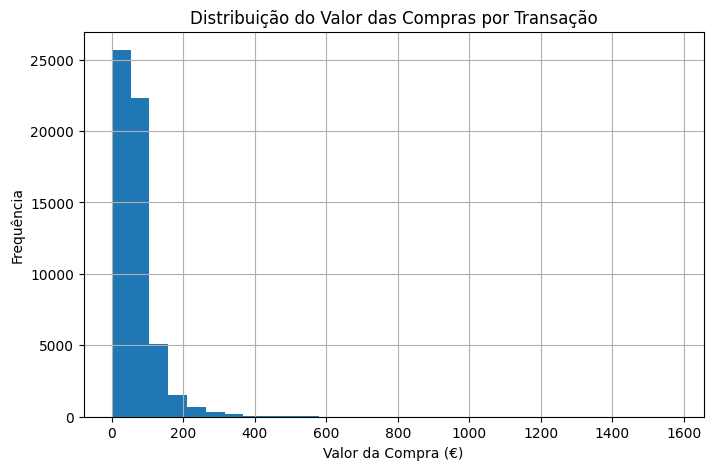

In [43]:
#Histograma da distribuição do valor das compras por transação
plt.figure(figsize=(8,5))

#bins=30 - número de intervalos do histograma
df_vendas['Total Compra c/IVA'].hist(bins=30)

plt.title("Distribuição do Valor das Compras por Transação")
plt.xlabel("Valor da Compra (€)")
plt.ylabel("Frequência")

plt.show()

A análise do valor das compras ao nível da transação revela uma **distribuição assimétrica positiva forte**, traduzida na grande concentração de transações com valor reduzido, maioritariamente abaixo dos 100€.

Este tipo de distribuição é comum em contexto de e-commerce, onde muitas compras de valor reduzido são acompanhadas de poucas compras com elevado valor.

#### **% de encomendas com portes**

***Criação da variável Portes***

In [44]:
#Criar variável binária 'Portes', sendo a política da empresa definida por portes grátis acima de 40€
df_vendas = df.drop_duplicates(subset='Ref Venda').copy()

#.astype(int) converte True/False em 1/0
df_vendas['Portes'] = (df_vendas['Total Compra c/IVA'] < 40).astype(int)

In [45]:
#Proporção de encomendas com e sem portes
((df_vendas['Portes'].value_counts(normalize=True) * 100)
 .round(2)
 .astype(str) + '%')

,proportion
Portes,
0,73.13%
1,26.87%


A política de envios definida pela empresa estabelece que os portes são gratuitos apenas em encomendas de valor igual ou superior a 40€. Desta forma, ao analisar a proporção de encomendas realizadas, constata-se que cerca de **73% das encomendas não têm custos de envio associados**, enquanto apenas aproximadamente 27% das encomendas apresenta o pagamento de portes no valor de 3,90€. Desta forma, conclui-se que a grande maioria das encomendas apresenta valores acima dos 40€.

O comportamento de compra verificado nas situações de ausência de custos de envio pode indicar compras ocasionais, que pode levar à necessidade de uma análise mais detalhada do valor médio das transações e das ações de retenção.

***Verificação de casos anómalos relacionados com portes***

In [46]:
#Verificar encomendas anómalas onde o valor total é inferior ao valor mínimo dos portes (3.90€)
df_display = df_vendas[df_vendas['Total Compra c/IVA'] < 3.9].copy()
# Anonimizar colunas identificáveis
for col in ['Nome do Cliente', 'E-Mail', 'Telemóvel']:
    if col in df_display.columns:
        df_display[col] = [f'[Anonimizado_{i:03d}]' for i in range(len(df_display))]
df_display

,Data,Ref Venda,Ref Cliente,Nome do Cliente,E-Mail,Telemóvel,Ref Produto,Nome do Produto,Qt,Preço Produto c/IVA,Tipo,Categoria,Subcategoria,Marca,Pagamento,Total Compra c/IVA,Desconto,Preco_Unitario,Portes
352,2016-08-11,165,172,[Anonimizado_000],[Anonimizado_000],[Anonimizado_000],3702,Cruzeta Plástico 12mm,3.0,2.55,Aves,Acessórios Diversos,NaN,NaN,Transferência Bancária,3.80,0.0,0.85,1
374,2016-08-18,175,57,[Anonimizado_001],[Anonimizado_001],[Anonimizado_001],862,Tê de 12mm para Bebedouros Automáticos,2.0,0.38,Aves,Acessórios Diversos,NaN,Diversos,Transferência Bancária,3.18,0.0,0.19,1
2900,2017-06-06,1140,924,[Anonimizado_002],[Anonimizado_002],[Anonimizado_002],2760,Pepino Inglês Comprido - 10 gr,3.0,2.40,Jardim/Agricultura,Sementes,Horticolas,Flora Lusitana,Transferência Bancária,2.40,0.0,0.80,1
31217,2020-05-21,11059,5244,[Anonimizado_003],[Anonimizado_003],[Anonimizado_003],491,Art.134 - Bebedouro Sifone Firenze - 200ml (Br...,1.0,0.60,Aves,Comedouros/Bebedouros,NaN,2G-R,Cartão de Crédito ou Paypal,0.60,0.0,0.60,1
43486,2021-01-15,15053,1,[Anonimizado_004],[Anonimizado_004],[Anonimizado_004],844,Art.85 - Poleiro Plastico 5cm,1.0,0.17,Aves,Poleiros,NaN,2G-R,MB Way,0.17,0.0,0.17,1
43487,2021-01-15,15054,1,[Anonimizado_005],[Anonimizado_005],[Anonimizado_005],844,Art.85 - Poleiro Plastico 5cm,1.0,0.17,Aves,Poleiros,NaN,2G-R,MB Way,0.17,0.0,0.17,1
48017,2021-03-12,16415,6881,[Anonimizado_006],[Anonimizado_006],[Anonimizado_006],558,Art.25/G - Comedouro Universal c/Grelha,2.0,3.30,Aves,Comedouros/Bebedouros,NaN,2G-R,Cartão de Crédito ou Paypal,3.30,0.0,1.65,1
68798,2022-03-02,23432,3537,[Anonimizado_007],[Anonimizado_007],[Anonimizado_007],273,Ninho de Agapornis,1.0,3.45,Aves,Ninhos,Ninhos Madeira,Diversos,MB Way,3.45,0.0,3.45,1
86773,2023-02-23,30145,10450,[Anonimizado_008],[Anonimizado_008],[Anonimizado_008],4932,Coleira Max Biocide Cães 38cm,1.0,3.00,Cães,Farmácia,Antiparasitários,Max Biocide,MB Way,3.00,0.0,3.00,1
148636,2026-02-04,54391,6755,[Anonimizado_009],[Anonimizado_009],[Anonimizado_009],4496,Porta Verduras/Fibras Plástico,10.0,2.50,Aves,Acessórios Diversos,NaN,2G-R,MB Way,2.50,0.0,0.25,1


De forma a identificar anomalias nos dados ao nível dos custos de envios, analisou-se as encomendas, cujo valor total é inferior ao valor dos portes (3,90€), sendo que nestes casos seria claramente obrigatório haver cobrança de custos de envio.

A partir da análise realizada, foram identificados **10 casos em que não foram cobrados portes** em encomendas com valor inferior a 3,90€. A justificação para estes casos pode estar relacionada com eventuais falhas no sistema ou a testes de configuração de portes realizados pela própria equipa da empresa e pela agência responsável pelo site.

#### **Quantidade por venda**

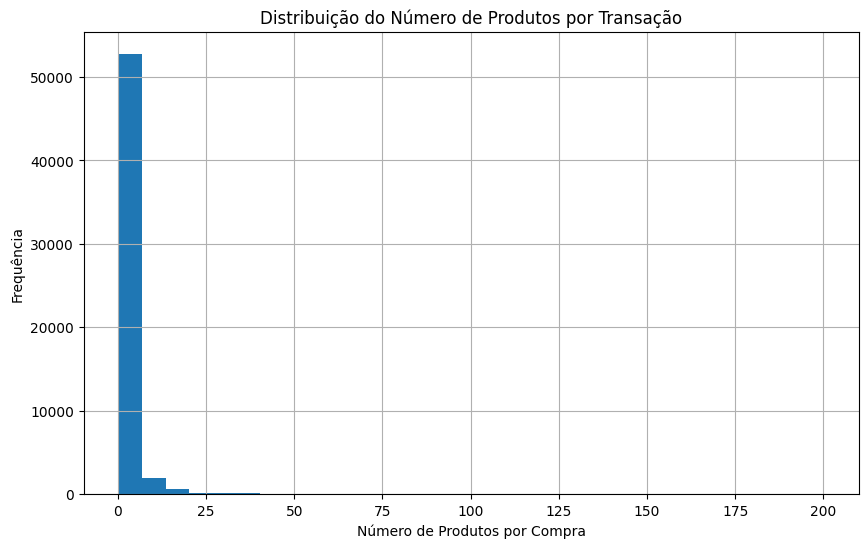

In [47]:
#Distribuição do número de produtos por venda
plt.figure(figsize=(10,6))

#groupby + sum() - soma das quantidades dos produtos comprados em cada venda
qt_por_venda = df_vendas.groupby('Ref Venda')['Qt'].sum()

qt_por_venda.hist(bins=30)

plt.title("Distribuição do Número de Produtos por Transação")
plt.xlabel("Número de Produtos por Compra")
plt.ylabel("Frequência")

plt.show()

Tal como acontece na distribuição do valor das vendas, o número de produtos por transação apresenta uma **distribuição assimétrica positiva forte**, revelando que a grande maioria das transações é composta por um número reduzido de produtos. Como tal, sugere-se um padrão de comportamento associado a compras menos volumosas, mais simples e ocasionais.

#### **Vendas por tipo**

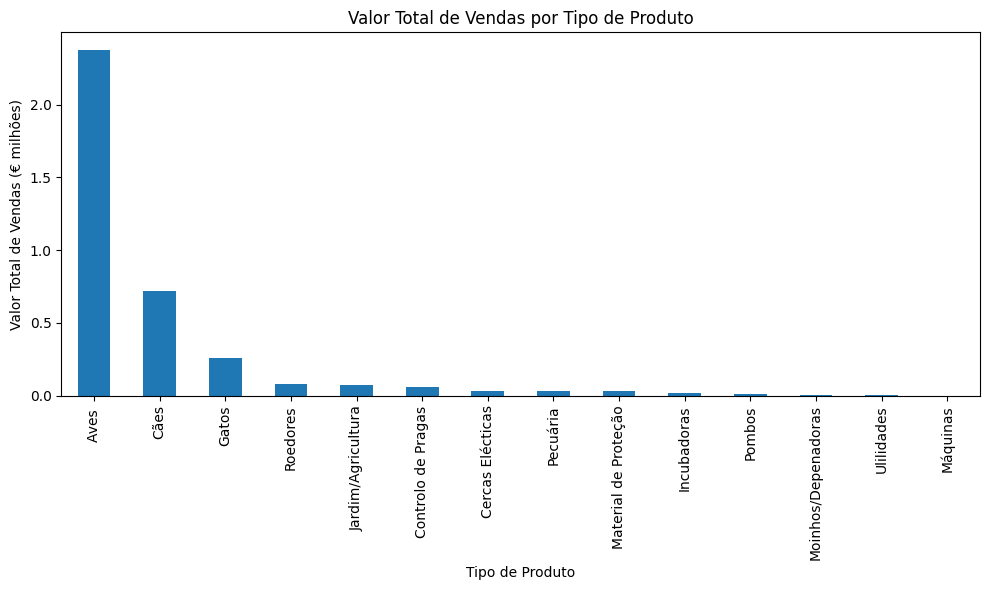

In [48]:
#Valor total de vendas por Tipo de produto (segmento de negócio)
plt.figure(figsize=(10,6))

vendas_tipo = df_vendas.groupby('Tipo')['Total Compra c/IVA'].sum().sort_values(ascending=False)

#Dividir por 1 milhão para melhor legibilidade no eixo Y
(vendas_tipo / 1_000_000).plot(kind='bar')

plt.title("Valor Total de Vendas por Tipo de Produto")
plt.xlabel("Tipo de Produto")
plt.ylabel("Valor Total de Vendas (€ milhões)")

plt.tight_layout()
plt.show()

A análise do valor total de vendas por tipo de produto revela que o core do negócio está relacionado com a venda de produtos para **aves**, seguindo-se os segmentos de cães, gatos e roedores, que ocupam, respetivamente, os 2º, 3º e 4º lugares. Como tal, o segmento de animais de estimação é dominante em comparação com a componente agrícola.

#### **Frequência de tipos**

In [49]:
#Frequência absoluta de vendas por Tipo de produto
df_vendas['Tipo'].value_counts()

,count
Tipo,
Aves,34912
Cães,9891
Gatos,3949
Roedores,1570
Controlo de Pragas,1340
Jardim/Agricultura,1034
Pecuária,524
Material de Proteção,445
Cercas Elécticas,241


In [50]:
#Frequência relativa (%) de vendas por Tipo
((df_vendas['Tipo'].value_counts(normalize=True) * 100)
 .round(2)
 .astype(str) + '%')

,proportion
Tipo,
Aves,64.34%
Cães,18.23%
Gatos,7.28%
Roedores,2.89%
Controlo de Pragas,2.47%
Jardim/Agricultura,1.91%
Pecuária,0.97%
Material de Proteção,0.82%
Cercas Elécticas,0.44%


Ao avaliar a frequência de vendas por tipo, confirma-se a predominância de vendas para o **segmento de aves**, representando **34.912 vendas** num total de 54.262 vendas com valor associado à variável `Tipo`. Desta forma, o segmento de Aves totaliza cerca de **64,34%** do total de vendas realizadas no período em análise.

#### **Média do valor gasto por Tipo**

In [51]:
#Valor médio gasto em cada Tipo de produto (ticket médio por linha)
((df.groupby('Tipo')['Total Compra c/IVA'].mean())
 .round(2)
 .astype(str) + '€')

,Total Compra c/IVA
Tipo,
Aves,80.68€
Cercas Elécticas,179.71€
Controlo de Pragas,63.06€
Cães,82.89€
Gatos,77.71€
Incubadoras,155.66€
Jardim/Agricultura,62.73€
Material de Proteção,81.13€
Moinhos/Depenadoras,408.43€


De forma a complementar a análise das vendas da empresa, é relevante avaliar o **valor médio gasto por tipo de produto**. A partir desta análise, verifica-se que os 3 setores com valor médio mais elevado são, respetivamente, Moinhos/Depenadoras (408,43€ em média), Cercas Elétricas (179,71€ em média) e Incubadoras (155,66€ em média).

Estes resultados surgem pelo facto de que nestes segmentos os produtos serem substancialmente mais caros do que noutros tipos. Nos restantes tipos de produtos os valores médios variam entre os 61,24€ e os 87,44€, não havendo variabilidade significativa.

#### **Vendas por categoria**

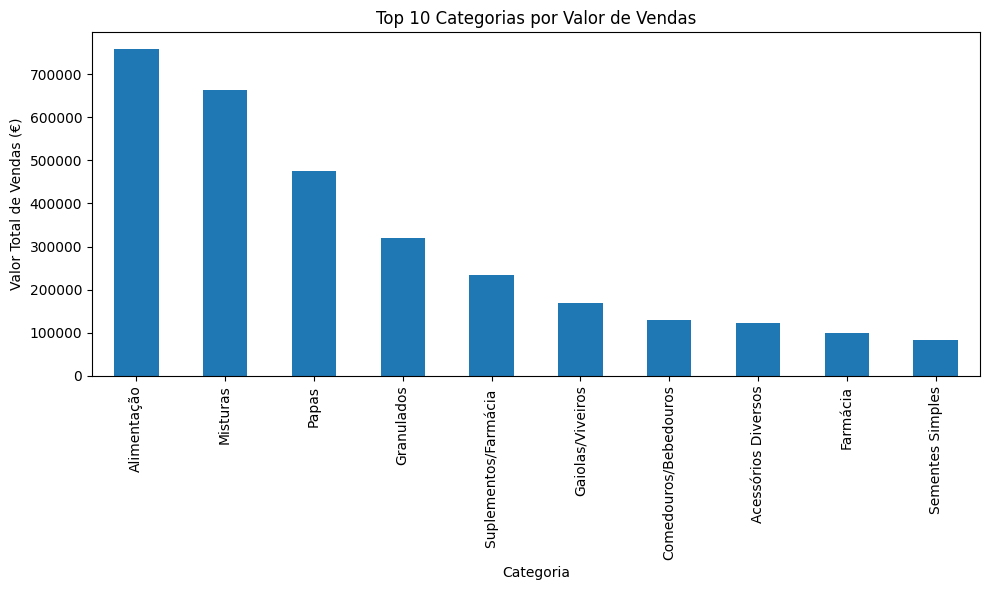

In [52]:
#Top 10 categorias por valor total de vendas
vendas_categoria = (
    df_vendas.groupby('Categoria')['Total Compra c/IVA']
    .sum()
    .sort_values(ascending=False)
)

#Selecionar apenas o top 10
top10 = vendas_categoria.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind='bar')

plt.title("Top 10 Categorias por Valor de Vendas")
plt.xlabel("Categoria")
plt.ylabel("Valor Total de Vendas (€)")

plt.tight_layout()
plt.show()

A análise às vendas por categoria de produto revela que as **5 categorias com maior valor de faturação** consistem:

**1ª. Alimentação -** unindo a alimentação de cães, gatos e roedores, pois as categorias apresentam exatamente a mesma designação

**2ª. Misturas -** categoria de produtos do tipo aves

**3ª. Papas -** categoria de produtos do tipo aves

**4ª. Granulados -** categoria de produto do tipo aves

**5ª. Suplementos/Farmácia -** categoria de produto do tipo de aves

Esta análise permite confirmar, mais uma vez, que existe uma maior concentração de valor de faturação associada ao segmento de Aves.

#### **Frequência de categorias**

In [53]:
#Frequência absoluta de vendas por Categoria
df_vendas['Categoria'].value_counts()

,count
Categoria,
Alimentação,10216
Misturas,8483
Papas,7294
Suplementos/Farmácia,4344
Granulados,4013
...,...
Suplementos,6
Criadeiras e Aquecimento,6
Coleiras/Peitorais,4


Ao analisar os resultados obtidos na análise de **frequência de vendas por categoria**, verifica-se uma ligeira alteração do top 5 em comparação com o valor faturado por categoria, estando essa alteração associada à alteração da posição entre os Granulados e os Suplementos/Farmácia.

#### **Métodos de pagamento**

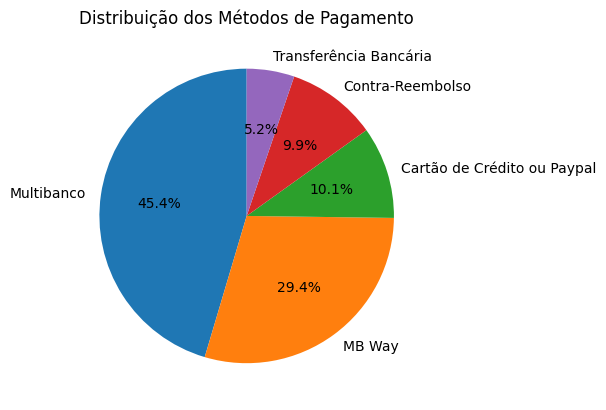

In [54]:
#Distribuição dos métodos de pagamento utilizados
pagamentos = df_vendas['Pagamento'].value_counts()

plt.figure(figsize=(6,6))

#Gráfico circular (pie) - autopct mostra a percentagem em cada fatia
pagamentos.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    ylabel=''
)

plt.title("Distribuição dos Métodos de Pagamento")

plt.tight_layout()
plt.show()

Ao analisar a distribuição dos métodos de pagamento utilizados para concretizar as encomendas, verifica-se que o método de pagamento preferido dos clientes da empresa consiste no pagamento via **referência multibanco**, representando **45,4%** do total de pagamentos realizados. O 2º método mais utilizado está associado ao MB Way, sendo um método cada vez mais utilizado pela sua praticidade e simplicidade (29,4%). O método menos representativo consiste na transferência bancária, perfazendo 5,2% dos pagamentos realizados.

### **Clientes:** ###

#### **Top clientes**

In [55]:
#Top 10 clientes por valor total gasto
df_display = df_clientes.sort_values('Monetary', ascending=False).head(10).copy()
# Anonimizar colunas identificáveis
for col in ['Nome do Cliente', 'E-Mail', 'Telemóvel']:
    if col in df_display.columns:
        df_display[col] = [f'[Anonimizado_{i:03d}]' for i in range(len(df_display))]
df_display

,Ref Cliente,Nome do Cliente,Frequency,Monetary,Ultima_Compra
3889,4974,[Anonimizado_000],77,18431.09,2026-03-17
34,46,[Anonimizado_001],174,17118.77,2026-03-29
2439,3165,[Anonimizado_002],153,15516.44,2026-03-25
2460,3189,[Anonimizado_003],108,15403.23,2026-03-28
5053,6424,[Anonimizado_004],149,14952.99,2026-03-19
329,439,[Anonimizado_005],117,14206.41,2026-03-19
242,326,[Anonimizado_006],117,13320.79,2026-03-18
640,832,[Anonimizado_007],158,13283.57,2026-03-10
5681,7175,[Anonimizado_008],64,11987.95,2026-03-27
1388,1817,[Anonimizado_009],100,11686.32,2026-03-31


O **top 10 dos clientes associado ao total gasto** é apresentado acima, sendo composto na totalidade por clientes que realizaram a sua última compra no mais recente mês de análise, revelando que se tratam de clientes que mantêm ainda uma relação com a empresa.

Ao nível do valor gasto, constata-se que o cliente mais representativo já gastou um total de 18.431,09€ num total de 77 compras realizadas, enquanto que o 10º cliente com maior volume de despesas (11.686,32€) apresenta um número superior de compras apesar de um total gasto inferior.

No top 10 identificado, o cliente com maior número de compras apresenta a referência 46, indicando que é um cliente com uma relação extremamente satisfatória com a empresa, tendo realizado um total de 174 compras ao longo do seu histórico.

#### **Número de compras por cliente**

In [56]:
#Estatísticas descritivas do número de compras por cliente
df_clientes['Frequency'].describe()

,Frequency
count,13074.000000
mean,4.281092
std,9.564390
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,174.000000


Ao analisar as estatísticas descritivas associadas ao número de compras realizadas na empresa em estudo, contabiliza-se que num total de 13.074 clientes distintos o número de compras varia entre um **mínimo de 1** e um **máximo de 174**, conforme referido anteriormente. A média obtida de aproximadamente 4 compras por cliente dá a entender um nível razoável de atividade.

Contudo, a mediana e o 1º quartil indicam que a maioria dos clientes realizou apenas 1 compra. O 3º quartil com o valor de 3 compras reforça que 75% dos clientes realizaram até 3 compras. Desta forma, a diferença evidenciada entre a média e a mediana sugere uma assimetria na distribuição, dado que um pequeno número de clientes apresenta elevada frequência de compras.

Importa salientar que a heterogeneidade verificada entre clientes com reduzida e elevada frequência de compras é relevante para análise de churn e recompra, dado que clientes com menor frequência de compra tendem a apresentar maior probabilidade de abandono.

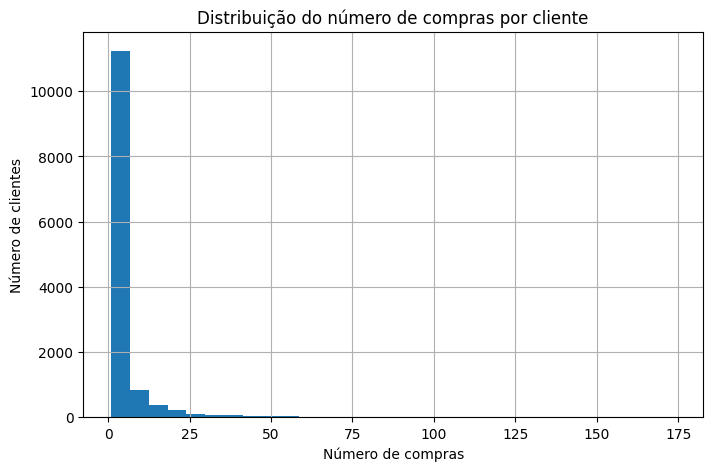

In [57]:
#Histograma do número de compras por cliente
plt.figure(figsize=(8,5))
df_clientes['Frequency'].hist(bins=30)
plt.title("Distribuição do número de compras por cliente")
plt.xlabel("Número de compras")
plt.ylabel("Número de clientes")
plt.show()

Conforme reforçado anteriormente, constata-se, a partir da análise do gráfico acima, que existe uma **distribuição assimétrica positiva forte** relativamente ao número de compras por cliente, evidenciando grande concentração em valores reduzidos.

In [58]:
#Contagem detalhada de clientes por número de compras
df_clientes['Frequency'].value_counts().sort_index()

,count
Frequency,
1,7553
2,1745
3,838
4,480
5,359
...,...
120,1
149,1
153,1


A partir da análise do número de compras por cliente, constata-se que existem **7.553 clientes que realizaram apenas 1 compra** no período em análise, evidenciando um elevado número de clientes que com estratégias de retenção bem delineadas se podem converter em clientes recorrentes.

#### **Valor gasto por cliente**

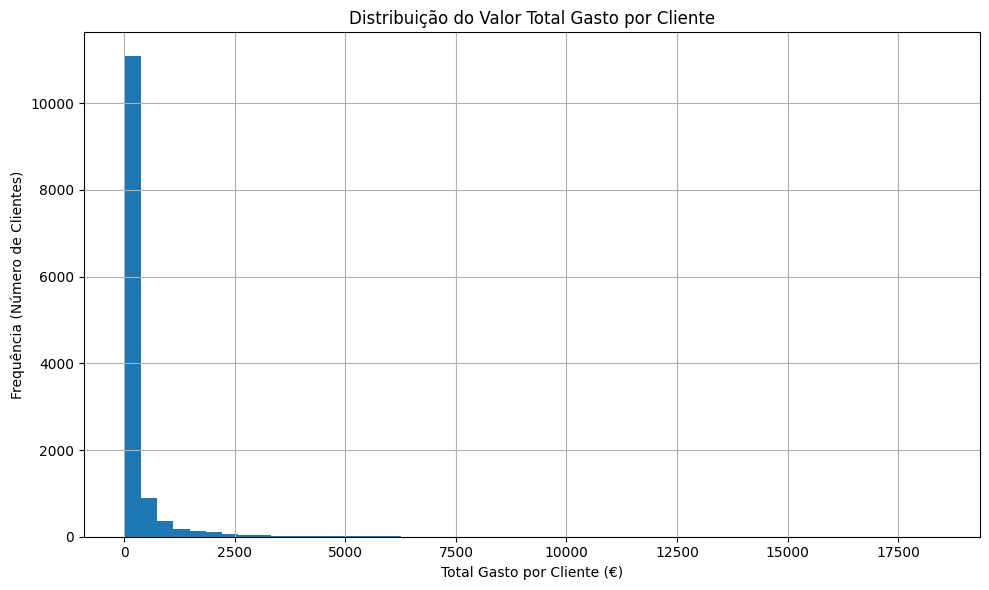

In [59]:
#Histograma do valor total gasto por cliente para visualização (limite máx. 20.000€)
plt.figure(figsize=(10,6))

#.clip(upper=20000) limita visualmente os outliers extremos para melhor leitura do gráfico
df_clientes['Monetary'].clip(upper=20000).hist(bins=50)

plt.title("Distribuição do Valor Total Gasto por Cliente")
plt.xlabel("Total Gasto por Cliente (€)")
plt.ylabel("Frequência (Número de Clientes)")

plt.tight_layout()
plt.show()

A distribuição do valor total gasto por cliente caracteríza-se por apresentar uma **assimetria positiva forte**, revelando um elevado número de clientes com um valor de despesa baixo, sendo consistente com os resultados observados anteriormente e com o contexto típico de e-commerce. Desta forma, a segmentação de clientes de acordo com o seu valor, complementado com frequência e recência, assume um papel preponderante nas estratégias de retenção e análise de churn.

####**Percentagem de receita dos top clientes**

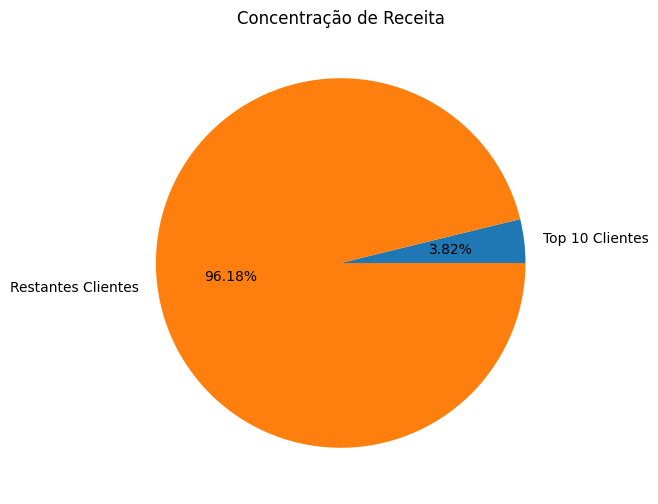

In [60]:
#Concentração de receita: quanto valem os top 10 clientes face ao total?
df_sorted = df_clientes.sort_values('Monetary', ascending=False)

top_10_valor = df_sorted.head(10)['Monetary'].sum()
total = df_sorted['Monetary'].sum()

#Gráfico circular com 2 fatias: top 10 vs restantes
plt.figure(figsize=(6,6))
plt.pie(
    [top_10_valor, total - top_10_valor],
    labels=['Top 10 Clientes', 'Restantes Clientes'],
    autopct='%1.2f%%',
)
plt.title("Concentração de Receita")
plt.show()

A análise à distribuição da receita pelos clientes revela que o **top 10 de clientes**, isto é, os 10 clientes com maior valor gasto nas suas compras ao longo do período em análise, **representam apenas 3,82% da receita total da empresa**. Como tal, constata-se que a empresa não está fortemente dependente de um reduzido número de clientes para gerar a maioria do seu volume de receitas.

Para a empresa, este resultado pode ser positivo numa avaliação de risco, na medida em que não se encontra "refém" de poucos clientes individuais. Desta forma, a perda de um destes clientes não se traduz num risco elevado de perda de receitas.

Por outro lado, ao nível de fidelização, estes resultados permitem inferir que existe menor capacidade de fidelização ou, mais especificamente, menor presença de clientes recorrentes caracterizados por um elevado valor de compra.

#### **Correlação ao nível do cliente**

<Axes: >

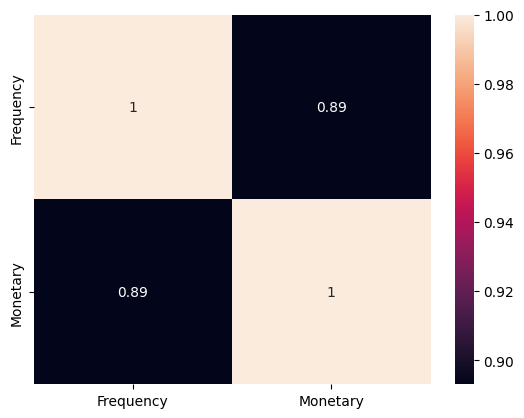

In [61]:
#Correlação entre número de compras e total gasto ao nível do cliente
#Esperada correlação positiva (mais compras → mais gasto)
corr = df_clientes[['Frequency', 'Monetary']].corr()

sns.heatmap(corr, annot=True)

A matriz de correlação ao nível do cliente apresentada entre as variáveis valor total gasto (`Monetary`) e o número de compras realizadas (`Frequency`) permite concluir que existe uma **forte correlação positiva** entre as mesmas, caracterizada por um **coeficiente de correlação de 0,89**. Como tal, este resultado evidencia que à medida que o número de compras de um cliente aumenta, o valor total gasto desse mesmo cliente também aumenta, sendo um resultado intuitivo.

Este resultado permite ainda concluir que a frequência de compra é um dos fatores determinantes para aferir o valor do cliente. Desta forma, ambas as variáveis analisadas são relevantes na caracterização dos clientes, mais especificamente, na componente de segmentação e análise de churn e recompra. Contudo, importa ter em consideração que a existência de uma elevada correlação entre ambas as variáveis deve ser devidamente ponderada no processo de seleção de features de forma a minimizar o risco de redundância e, consequentemente, multicolinearidade em determinados modelos.

### **Produtos:**

#### **Top produtos mais vendidos**

In [62]:
#Top 20 produtos mais vendidos (por quantidade acumulada)
top_produtos = (
    df.groupby(['Nome do Produto', 'Tipo'])['Qt']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

top_produtos

,Nome do Produto,Tipo,Qt
0,Comedouro/Bebedouro Cristal,Aves,5362.0
1,Art. 94 - Comedouro papa lusso,Aves,4557.0
2,Feno Nature Timothy Hay - 1kg,Roedores,4358.0
3,Art.85 - Poleiro Plastico 5cm,Aves,3964.0
4,Comedouro Cristal c/Gaveta,Aves,3582.0
5,"Mola Galv.60mm,fecho de Gaiolas",Aves,3327.0
6,"Mola INOX 60mm, fecho de Gaiolas",Aves,3070.0
7,Porta Verduras/Fibras Plástico,Aves,3032.0
8,Comedouro Cristal c/Cúpula,Aves,2963.0
9,IDIA - Bebedouro Leiria Base Transparente - 80...,Aves,2945.0


Ao analisar o **top 20 de produtos mais vendidos** da empresa, constata-se claramente que:
- Existe uma predominância de produtos associados a bebedouros, comedouros, ninhos e acessórios para Aves, refletindo a dominância deste setor no volume de negócios da empresa.

- Apenas um dos produtos não está associado ao tipo Aves, sendo o 3º classificado no top 20 (Feno Nature Timothy Hay - 1kg). Este produto é um bem alimentar para roedores.

- O produto mais vendido, Comedouro/Bebedouro Cristal, apresenta 5.362 unidades vendidas, havendo uma diferença ainda significativa para o 20º produto, que conta com 1.797 unidades vendidas.

Assim, sugere-se que existe um padrão de compras de produtos de menor valor, que se justifica por um elevado número de compras recorrentes e de necessidade frequente, tratando-se, neste caso específico, de acessórios para aves de desgaste rápido e que são comprados em grande quantidade devido ao elevado número de aves que os criadores possuem.

Estas conclusões são consistentes com o contexto de e-commerce, onde usualmente existe maior tendência para a compra frequente de produtos de menor valor.

#### **Frequência de marcas**

In [63]:
#Top 10 marcas mais frequentes nas linhas de venda
df['Marca'].value_counts().head(10)

,count
Marca,
Pet Cup,18009
Versele-Laga,12017
2G-R,10851
NutriBird,5534
EX,4777
Diversos,4413
Avizoon,4310
Orlux,4198
Deli Nature,3570


Por fim, é relevante analisar o **top 10 de marcas mais vendidas** na empresa, com o objetivo de confirmar os resultados observados ao longo da análise exploratória realizada. Como tal, constata-se que:
- A marca mais vendida é a Pet Cup, contabilizando 18.009 vendas, evidenciando uma forte presença no catálogo de produtos comercializado.

- Existe uma marca classificada com nome "Diversos" de forma a agrupar produtos sem marca específica atribuída, devendo ser tido em consideração na interpretação dos resultados, pois existe a possibilidade de agregar diferentes tipos de produtos e enviesar a análise por marca.

- A maioria das marcas, excetuando a Flora Lusitana, que ocupa o 10º lugar, está associada, em grande parte, à venda de produtos para o setor animal, em especial, para Aves, contribuindo para explicar a predominância deste setor na empresa.

## **10. Exportação de datasets**

In [64]:
#Exportação dos 3 dataframes para utilização nos notebooks seguintes
df.to_csv("/content/drive/MyDrive/df_linhas.csv", index=False)         #dataset linha de produto
df_vendas.to_csv("/content/drive/MyDrive/df_vendas.csv", index=False)   #dataset agregado por venda
df_clientes.to_csv("/content/drive/MyDrive/df_clientes.csv", index=False)  #dataset agregado por cliente

## **11. Principais Conclusões**

A análise exploratória de dados revelou-se essencial na identificação de padrões relacionados com as vendas, clientes e produtos, sendo de destacar as seguintes conclusões:

- **Crescimento sustentado das vendas ao longo do período de análise:** constatou-se que as vendas registaram uma tendência global de crescimento entre fevereiro de 2016 e março de 2026, havendo casos de oscilação mensal, passível de ser justificado por um contexto de desenvolvimento do negócio e de aumento da atividade comercial.

- **Presença de distribuições assimétricas positivas:** ao analisar o valor de compra, número de produtos, valor gasto por cliente, entre outras variáveis relevantes, são evidentes distribuições fortemente assimétricas positivas, destacando maior concentração de valores reduzidos. Estas conclusões coincidem com padrões típicos de e-commerce.

- **Clientes ocasionais são predominantes:** concluiu-se que a maioria dos clientes realiza apenas uma compra, sugerindo que a empresa detém uma carteira de clientes amplamente caracterizados como pouco recorrentes. Por outro lado, verificou-se que existem um reduzido grupo de clientes que apresenta elevada frequência de compra, contribuindo assim de forma mais significativa para o aumento da atividade comercial.

- **Reduzida concentração de receita:** constatou-se que o top 10 de clientes representa apenas 3,82% do total de receita, evidenciando uma distribuição equilibrada da receita sem forte dependência de clientes individuais.

- **Relação forte entre o valor gasto pelo cliente e a frequência de compra:** a correlação forte e positiva verificada entre as variáveis associadas ao número de compras e ao valor gasto pelo cliente confirmam que a frequência de compra assume-se como um fator preponderante para determinar o valor de um cliente.

- **Concentração de produtos de valor reduzido:** a análise aos produtos mais vendidos revelou que o top 20 tende a ser composto por produtos para aves com um preço unitário extremamente reduzido, evidenciando um volume de vendas caracterizado por produtos de consumo recorrente, de desgaste rápido e associado ao número de animais que os clientes possuem.

- **Predominância do setor animal, especialmente das Aves:** concluiu-se a partir da análise dos atributos categóricos (tipo, categoria e marca do produto) que as vendas da empresa são fortemente associadas ao setor animal, com elevada concentração de produtos, em particular, direcionados a Aves. Desta forma, constata-se que existe elevada especialização neste segmento.

- **Qualidade global de dados elevada:** os processos de limpeza e validação permitiram aferir a qualidade dos dados, tendo-se verificado consistência dos dados nas variáveis mais relevantes na análise, assim como ausência de valores negativos em situações específicas que representariam situações anómalas (por exemplo, preço unitário ou quantidade ou total de compra inferior a 0). Além disso, a existência e tratamento de valores duplicados e omissos foi devidamente justificada, tendo em consideração o contexto de negócio.